# OnioRakshak — Shelf-Life Dataset: EDA & Preprocessing

This notebook explores the onion shelf-life dataset and builds the preprocessing
pipeline used before model training. Every step includes a short note on *why*
it matters, and EDA is broken out by `variety` throughout, since onion variety
turned out to be one of the more interesting splits in this data.

Figures are saved to `notebooks/figures/` as we go


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

sns.set_theme(style="whitegrid")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved {path}")


## 1. Load Data & Basic Overview

**Why this matters:** before touching features or models, we need to confirm
the dataset's shape, check for missing values, and see what data types we're
working with. Skipping this step is how silent bugs (e.g. a numeric column
read as text) sneak into a whole pipeline.


In [16]:
df = pd.read_csv("../data/onion_shelf_life_dataset.csv")
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None — dataset is clean.")
df.head()


Shape: (21780, 21)

Missing values per column:
None — dataset is clean.


,batch_id,storage_day,variety,storage_mode,initial_quality_score,curing_score,initial_weight_kg,temperature_C,relative_humidity_pct,mq135_gas_index,...,avg_humidity_24h_pct,avg_mq135_24h,hours_temp_above_27C_24h,hours_RH_above_65pct_24h,weight_loss_pct,decay_pct,sprouting_pct,remaining_shelf_life_days,usable_storage_endpoint_day,data_type
0,B042,17,Red,Ventilated_ambient,0.829,0.946,10.717,35.83,65.17,158.53,...,65.02,157.94,19.64,0.53,1.46,0.00,0.00,94,111,synthetic_research_anchored
1,B111,86,Red,Warm_ambient,0.843,0.735,12.769,29.72,83.77,306.10,...,83.98,308.41,7.48,19.80,5.75,100.00,100.00,0,78,synthetic_research_anchored
2,B021,113,Red,Ventilated_ambient,0.949,0.939,19.361,29.97,69.79,274.18,...,69.67,275.52,7.89,4.56,5.68,85.79,99.58,0,90,synthetic_research_anchored
3,B121,22,Yellow,Warm_ambient,0.895,0.686,13.704,33.59,65.45,189.66,...,64.87,191.30,17.55,0.75,1.32,0.00,0.25,79,101,synthetic_research_anchored
4,B048,14,Red,Warm_ambient,0.876,0.980,10.410,36.18,79.02,197.95,...,78.76,199.65,21.27,12.89,1.29,0.69,0.41,106,120,synthetic_research_anchored


In [17]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
batch_id,21780,180,B042,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storage_day,21780.0,NaN,NaN,NaN,60.0,34.9293,0.0,30.0,60.0,90.0,120.0
variety,21780,3,Red,11616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storage_mode,21780,3,Ventilated_ambient,11132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
initial_quality_score,21780.0,NaN,NaN,NaN,0.884739,0.06034,0.677,0.85175,0.8835,0.923,0.99
curing_score,21780.0,NaN,NaN,NaN,0.812983,0.093862,0.6,0.742,0.8095,0.893,0.98
initial_weight_kg,21780.0,NaN,NaN,NaN,13.980094,3.587842,8.039,11.112,13.638,17.08375,19.921
temperature_C,21780.0,NaN,NaN,NaN,30.027937,3.817389,20.15,27.22,29.79,32.51,44.97
relative_humidity_pct,21780.0,NaN,NaN,NaN,69.614265,7.847718,48.33,63.73,69.0,74.75,92.0
mq135_gas_index,21780.0,NaN,NaN,NaN,208.504824,55.954529,113.78,162.2975,186.425,252.3725,354.7


## 2. Target Variable: `remaining_shelf_life_days`

**Why this matters:** understanding the target's shape (skew, range, spread)
tells us whether a plain regression will struggle with outliers, and whether
we need to look at subgroups (like variety) separately rather than pooling
everything together.


C:\Users\sai\AppData\Local\Temp\ipykernel_15496\758296723.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="variety", y="remaining_shelf_life_days", ax=axes[1],


Saved figures\01_target_distribution_by_variety.png


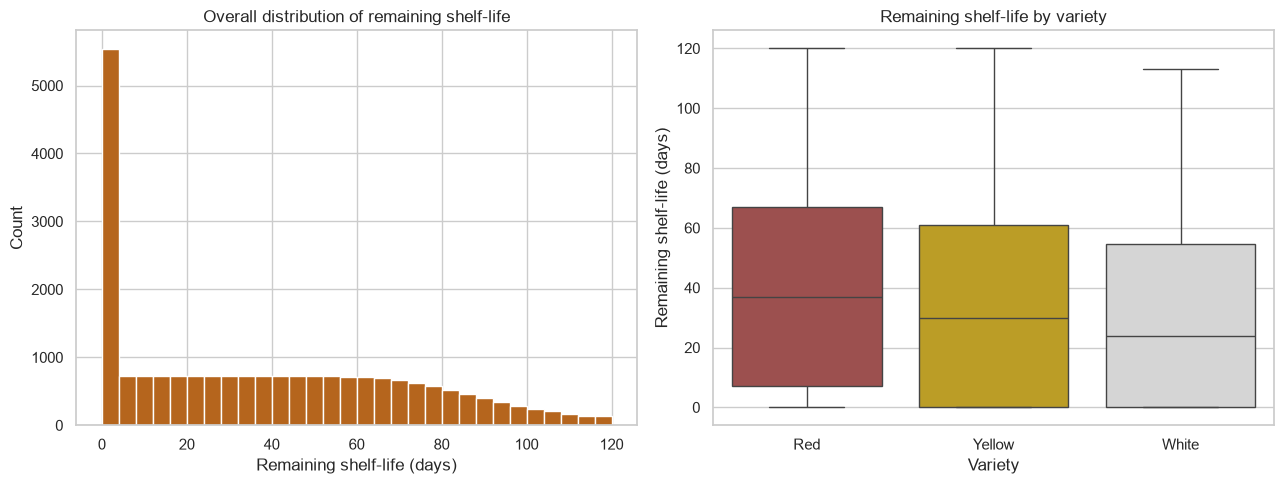

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["remaining_shelf_life_days"], bins=30, color="#b5651d", edgecolor="white")
axes[0].set_title("Overall distribution of remaining shelf-life")
axes[0].set_xlabel("Remaining shelf-life (days)")
axes[0].set_ylabel("Count")

sns.boxplot(data=df, x="variety", y="remaining_shelf_life_days", ax=axes[1],
            palette={"Red": "#a94442", "Yellow": "#d4ac0d", "White": "#d5d5d5"})
axes[1].set_title("Remaining shelf-life by variety")
axes[1].set_xlabel("Variety")
axes[1].set_ylabel("Remaining shelf-life (days)")

plt.tight_layout()
save_fig(fig, "01_target_distribution_by_variety.png")
plt.show()


**Reading this:** the overall distribution is right-skewed — most batches spoil
faster than the long tail suggests. Splitting by variety shows Red onions
consistently store longest, White the shortest — this is useful context for
farmers deciding which variety to prioritize for long-term storage.


## 3. Storage Mode × Variety Interaction

**Why this matters:** storage mode is something a farmer can actually control
(ventilation, curtain use). Seeing how much it matters *within* each variety
tells us whether one control strategy fits all varieties, or whether
variety-specific thresholds are needed later.


Saved figures\02_variety_storage_mode_interaction.png


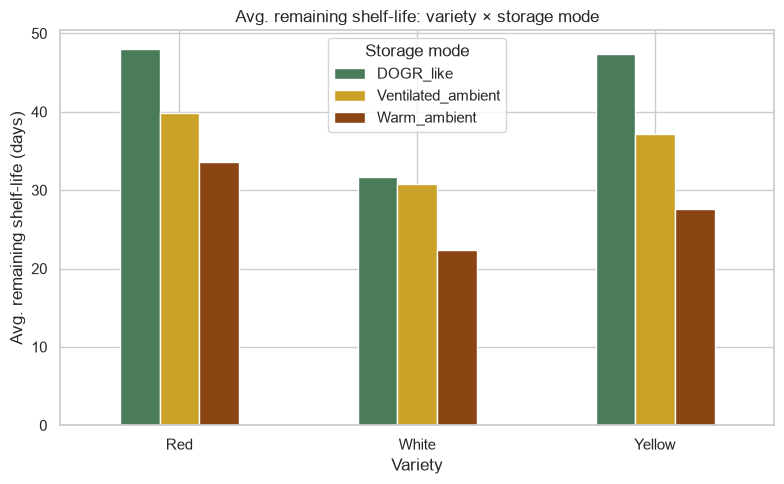

storage_mode,DOGR_like,Ventilated_ambient,Warm_ambient
variety,,,
Red,48.0,39.8,33.6
White,31.7,30.8,22.3
Yellow,47.4,37.1,27.6


In [19]:
pivot = df.groupby(["variety", "storage_mode"])["remaining_shelf_life_days"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax, color=["#4a7c59", "#c9a227", "#8b4513"])
ax.set_title("Avg. remaining shelf-life: variety × storage mode")
ax.set_ylabel("Avg. remaining shelf-life (days)")
ax.set_xlabel("Variety")
ax.legend(title="Storage mode")
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, "02_variety_storage_mode_interaction.png")
plt.show()
pivot.round(1)


**Reading this:** the storage-mode effect holds across all three varieties —
DOGR-like storage outperforms warm ambient regardless of variety — meaning
the actuator control logic doesn't need to be variety-specific, which
simplifies the embedded system's control rules.


## 4. Sensor Reading Distributions by Variety

**Why this matters:** if sensor readings *themselves* differ meaningfully by
variety (not just the outcome), that's a sign variety should stay in the
model as a feature rather than being dropped for simplicity.


C:\Users\sai\AppData\Local\Temp\ipykernel_15496\2972195457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="variety", y=col, ax=ax,
C:\Users\sai\AppData\Local\Temp\ipykernel_15496\2972195457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="variety", y=col, ax=ax,
C:\Users\sai\AppData\Local\Temp\ipykernel_15496\2972195457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="variety", y=col, ax=ax,


Saved figures\03_sensor_distributions_by_variety.png


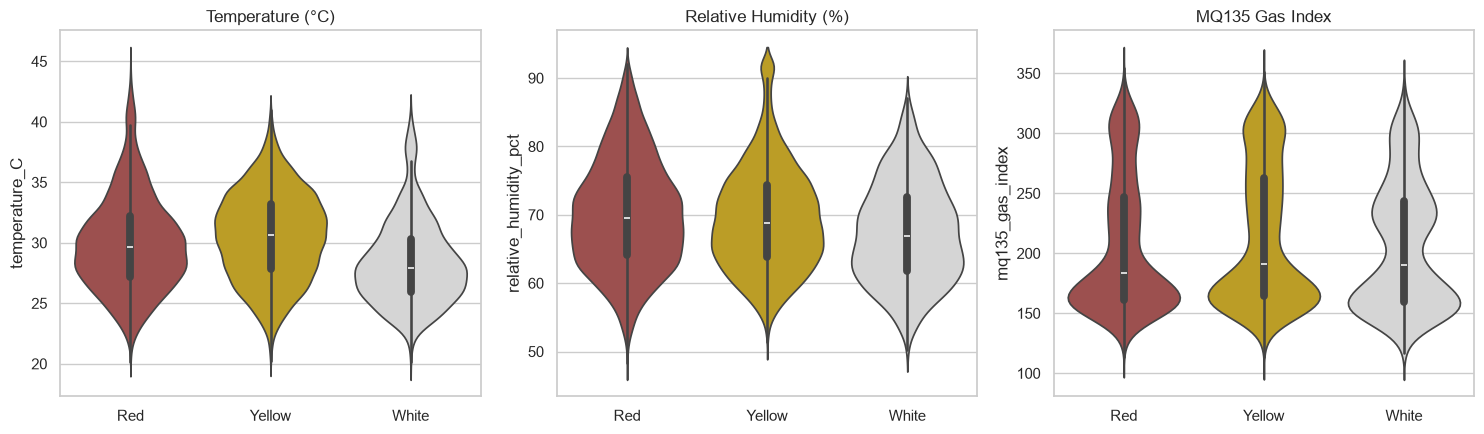

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sensor_cols = ["temperature_C", "relative_humidity_pct", "mq135_gas_index"]
titles = ["Temperature (°C)", "Relative Humidity (%)", "MQ135 Gas Index"]

for ax, col, title in zip(axes, sensor_cols, titles):
    sns.violinplot(data=df, x="variety", y=col, ax=ax,
                    palette={"Red": "#a94442", "Yellow": "#d4ac0d", "White": "#d5d5d5"})
    ax.set_title(title)
    ax.set_xlabel("")

plt.tight_layout()
save_fig(fig, "03_sensor_distributions_by_variety.png")
plt.show()


## 5. Correlation with Target

**Why this matters:** this tells us, before any modeling, which raw signals
are actually worth their place as model inputs — and flags features that
might be redundant with each other (e.g. instantaneous vs. 24h-average
readings).


Saved figures\04_correlation_heatmap.png


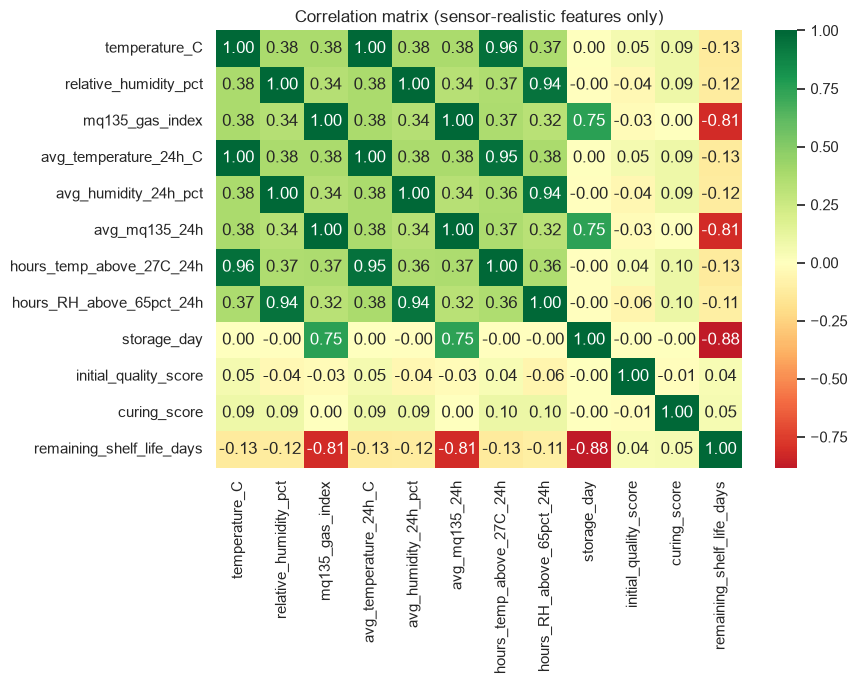

In [21]:
num_cols = [
    "temperature_C", "relative_humidity_pct", "mq135_gas_index",
    "avg_temperature_24h_C", "avg_humidity_24h_pct", "avg_mq135_24h",
    "hours_temp_above_27C_24h", "hours_RH_above_65pct_24h",
    "storage_day", "initial_quality_score", "curing_score",
    "remaining_shelf_life_days",
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Correlation matrix (sensor-realistic features only)")
plt.tight_layout()
save_fig(fig, "04_correlation_heatmap.png")
plt.show()


**Reading this:** `mq135_gas_index` and `storage_day` dominate — the gas
sensor is doing most of the real predictive work among the physical sensors.
Temperature and humidity correlate weakly on their own, but note they're
still useful as *threshold* features (`hours_temp_above_27C_24h` etc.) rather
than raw values — worth keeping in the model even though their direct
correlation looks modest.

**Important — features intentionally excluded:** `weight_loss_pct`,
`decay_pct`, and `sprouting_pct` are *not* included here even though they're
in the raw dataset and correlate very strongly with the target. They are
symptoms of spoilage, not something our ESP32 + DHT22/MQ135 sensors can
measure in the field, so training on them would silently make the model
useless once wired to real hardware. This is a modeling decision, not an
oversight.


## 6. Gas Index vs. Remaining Shelf-Life, by Variety

**Why this matters:** the strongest single sensor predictor deserves a closer
look — specifically whether the relationship holds the same way across
varieties, or whether one variety behaves differently (which would suggest
variety-specific gas thresholds).


Saved figures\05_gas_index_vs_shelf_life_by_variety.png


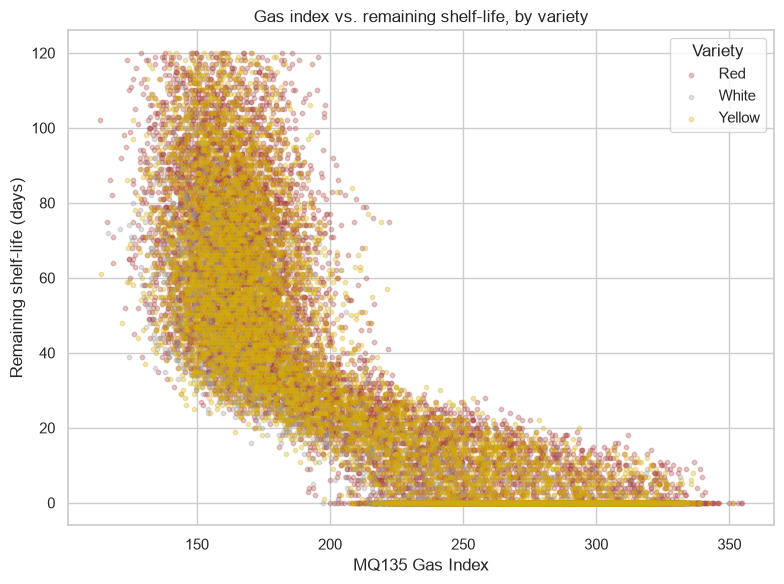

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = {"Red": "#a94442", "Yellow": "#d4ac0d", "White": "#999999"}
for variety, group in df.groupby("variety"):
    ax.scatter(group["mq135_gas_index"], group["remaining_shelf_life_days"],
               alpha=0.3, s=10, label=variety, color=palette[variety])
ax.set_xlabel("MQ135 Gas Index")
ax.set_ylabel("Remaining shelf-life (days)")
ax.set_title("Gas index vs. remaining shelf-life, by variety")
ax.legend(title="Variety")
plt.tight_layout()
save_fig(fig, "05_gas_index_vs_shelf_life_by_variety.png")
plt.show()


**Reading this:** the downward relationship (higher gas index → less
remaining shelf-life) holds consistently across all three varieties, with no
obvious variety-specific offset — reinforcing that a single shared model
(rather than one model per variety) is a reasonable choice, as long as
`variety` is kept as an input feature.


---
# Preprocessing Pipeline

The sections below build the preprocessing pipeline step by step, each with
the reasoning for why it's needed, before final feature sets are handed to
model training (see `src/train_shelf_life_model.py` for the production
version of this pipeline).


## 7. Cleaning

**Why this matters:** models trained on dirty data quietly learn dirty
patterns. Even though this dataset is already clean, this is where we'd
catch duplicate rows or impossible sensor values before they contaminate
training.


In [23]:
print("Duplicate rows:", df.duplicated().sum())
print("Temperature range:", df["temperature_C"].min(), "-", df["temperature_C"].max())
print("Humidity range:", df["relative_humidity_pct"].min(), "-", df["relative_humidity_pct"].max())
# No duplicates, no impossible sensor ranges — dataset needs no cleaning steps here.
# Once real ESP32 data comes in, add: interpolation for short sensor dropout gaps,
# and IQR/z-score based outlier flags for spurious spikes.


Duplicate rows: 0
Temperature range: 20.15 - 44.97
Humidity range: 48.33 - 92.0


## 8. Batch-Aware Train/Test Split

**Why this matters:** rows from the same `batch_id` share a single decay
trajectory. A random row-level split would let the model see readings from
day 50 of a batch while being tested on day 40 of the *same* batch —
leaking future information. Splitting by batch avoids this.


In [24]:
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["batch_id"]))
train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]
print(f"Train batches: {train_df['batch_id'].nunique()}, rows: {len(train_df)}")
print(f"Test batches:  {test_df['batch_id'].nunique()}, rows: {len(test_df)}")
assert set(train_df["batch_id"]) & set(test_df["batch_id"]) == set(), "Batch leakage detected!"


Train batches: 144, rows: 17424
Test batches:  36, rows: 4356


## 9. Standardization (Z-score Scaling)

**Why this matters:** standardization centers each numeric feature to mean 0
and standard deviation 1. This matters for models sensitive to feature
scale (linear models, SVMs, distance-based methods) and keeps the pipeline
consistent even though our primary model (Random Forest) doesn't strictly
need it. The scaler is *fit only on training data* and reused on test data
to avoid leaking test-set statistics into training.


In [25]:
numeric_features = [
    "initial_quality_score", "curing_score", "temperature_C",
    "relative_humidity_pct", "mq135_gas_index", "avg_temperature_24h_C",
    "avg_humidity_24h_pct", "avg_mq135_24h", "hours_temp_above_27C_24h",
    "hours_RH_above_65pct_24h", "storage_day",
]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[numeric_features])
test_scaled = scaler.transform(test_df[numeric_features])

print("Before scaling (mq135_gas_index): mean=%.2f, std=%.2f" %
      (train_df["mq135_gas_index"].mean(), train_df["mq135_gas_index"].std()))
print("After scaling (mq135_gas_index):  mean=%.2f, std=%.2f" %
      (train_scaled[:, numeric_features.index("mq135_gas_index")].mean(),
       train_scaled[:, numeric_features.index("mq135_gas_index")].std()))


Before scaling (mq135_gas_index): mean=207.58, std=55.50
After scaling (mq135_gas_index):  mean=0.00, std=1.00


## 10. Normalization (Min-Max Scaling)

**Why this matters:** normalization rescales features to a fixed [0, 1]
range. This is preferred over standardization for bounded features and for
feeding into neural-network-style models, where inputs in a fixed range
train more stably. We compare it here so the difference is visible, even
though the production pipeline currently uses standardization for the
tree-based model.


Saved figures\06_standardization_vs_normalization.png


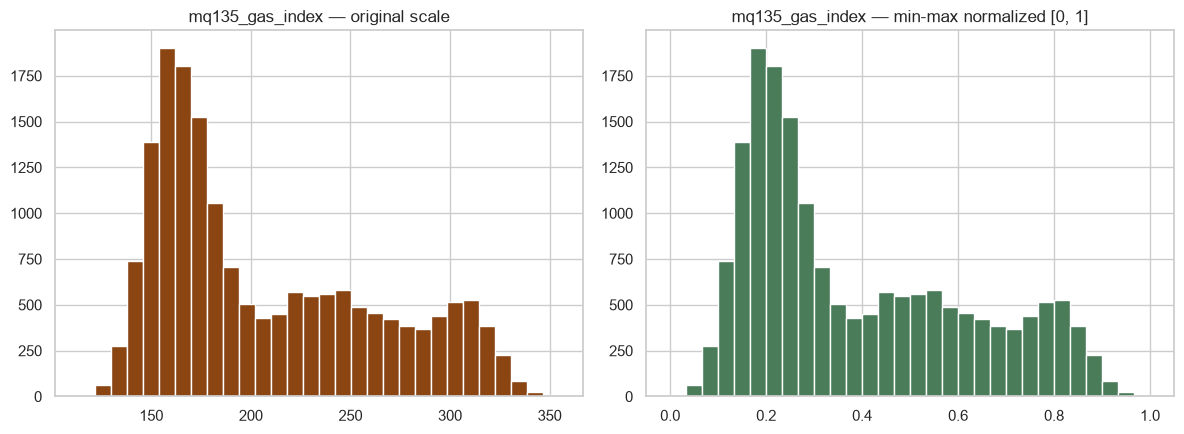

In [26]:
minmax = MinMaxScaler()
train_norm = minmax.fit_transform(train_df[numeric_features])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(train_df["mq135_gas_index"], bins=30, color="#8b4513")
axes[0].set_title("mq135_gas_index — original scale")
axes[1].hist(train_norm[:, numeric_features.index("mq135_gas_index")], bins=30, color="#4a7c59")
axes[1].set_title("mq135_gas_index — min-max normalized [0, 1]")
plt.tight_layout()
save_fig(fig, "06_standardization_vs_normalization.png")
plt.show()


## 11. Categorical Encoding

**Why this matters:** `variety` and `storage_mode` are categorical text
fields — models need numeric input, so we one-hot encode them into binary
indicator columns rather than arbitrarily assigning numbers (which would
falsely imply an order, e.g. Red > White).


In [27]:
categorical_features = ["variety", "storage_mode"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = ohe.fit_transform(train_df[categorical_features])
encoded_cols = ohe.get_feature_names_out(categorical_features)
pd.DataFrame(encoded, columns=encoded_cols).head()


,variety_Red,variety_White,variety_Yellow,storage_mode_DOGR_like,storage_mode_Ventilated_ambient,storage_mode_Warm_ambient
0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,1.0,0.0,0.0


## 12. Feature Extraction Recap

**Why this matters:** summarizing the final feature set makes the modeling
decisions explicit and auditable — useful for the IEEE paper's methodology
section, and for onboarding teammates to the pipeline.

Final features used for modeling:
- **Raw instantaneous sensor readings:** `temperature_C`, `relative_humidity_pct`, `mq135_gas_index`
- **24h rolling aggregates:** `avg_temperature_24h_C`, `avg_humidity_24h_pct`, `avg_mq135_24h`
- **Threshold/rate-of-change style features:** `hours_temp_above_27C_24h`, `hours_RH_above_65pct_24h`
- **Time feature:** `storage_day`
- **Intake-time manual entries:** `initial_quality_score`, `curing_score`
- **Categorical:** `variety`, `storage_mode` (one-hot encoded)
- **Explicitly excluded:** `weight_loss_pct`, `decay_pct`, `sprouting_pct` (spoilage symptoms, not sensor-measurable)


## 13. Summary of EDA Takeaways

- Dataset is clean and well-structured — no missing values, 180 batches, 3 varieties × 3 storage modes
- **Variety matters**: Red onions store longest on average, White the shortest
- **Storage mode matters more than variety**: the DOGR-like vs. warm-ambient gap (~15 days) is larger and holds consistently *within* every variety
- **`mq135_gas_index` is the standout sensor predictor** — far stronger than temperature or humidity alone, which supports prioritizing gas sensor reliability in the hardware design
- Temperature/humidity matter more as *threshold exposure* (hours above a limit) than as instantaneous readings
- All figures from this notebook are saved in `notebooks/figures/` for reuse in the README, slides, or the paper
